# HOMEWORK WEEK1_2

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

# Phần 1 - Thống kê mô tả & đặc trưng
  
  1.1.
  - Dữ liệu có 150 dòng, 5 cột
  - Kiểu dữ liệu từng cột:
    - sepal_length : chiều dài đài hoa(cm), kiểu dữ liệu float64
    - sepal_length : chiều rộng đài hoa(cm), kiểu dữ liệu float64
    - petal_length : chiều dài cánh hoa(cm), kiểu dữ liệu float64
    - petal_width  : chiều rộng cánh hoa(cm), kiểu dữ liệu float64
    - species      : loài hoa, kiểu dữ liệu object

  1.2 .

In [ ]:
numeric = df.select_dtypes(include="number")
analysis_table = pd.DataFrame({
    "Mean": numeric.mean(),
    "Median": numeric.median(),
    "Mode": numeric.mode().iloc[0],
    "Var": numeric.var(),
    "Std": numeric.std(),
    "Min": numeric.min(),
    "Max": numeric.max(),
    "Q1": numeric.quantile(0.25),
    "Q3": numeric.quantile(0.75),
    "IQR": numeric.quantile(0.75) - numeric.quantile(0.25)
})

print(analysis_table.round(3))


1.3.

In [ ]:
analysis_by_species = (
    df.groupby("species")[numeric.columns].agg(["mean", "std"])
)
print(analysis_by_species)

# Phần 2 - Phân phối xác suất

2.1.

In [ ]:

for col in numeric.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(col)
    plt.show()



## Nhận xét : 
- sepal_length và sepal_width có phân phối tương đối gần chuẩn, chỉ lệch nhẹ và có một đỉnh chính.
- petal_length và petal_width có phân phối nhiều đỉnh (multimodal), không tuân theo phân phối chuẩn do dữ liệu bao  gồm ba loài Iris với đặc trưng cánh hoa khác biệt rõ rệt.
- Trong bốn biến, petal_length và petal_width thể hiện khả năng phân biệt các loài tốt hơn vì sự tách biệt giữa các nhóm dữ liệu rõ ràng.


2.2. 

In [ ]:
for col in numeric.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(col)
    plt.show()

2.3.

In [ ]:
mean = df["sepal_length"].mean()
std = df["sepal_length"].std()

simulate = np.random.normal(
    loc=mean,
    scale=std,
    size=len(df)
)

x = np.linspace(
    df["sepal_length"].min(),
    df["sepal_length"].max(),
    100
)

y = norm.pdf(x, loc=mean, scale=std)

plt.figure(figsize=(8, 5))

sns.histplot(
    df["sepal_length"],
    stat="density",
    bins=20,
    kde=False,
    alpha=0.5,
    label="Real Data"
)

sns.histplot(
    simulate,
    stat="density",
    bins=20,
    kde=False,
    alpha=0.4,
    label="Simulated Data"
)

plt.plot(
    x,
    y,
    linewidth=2,
    color="brown",
    label="Theoretical Normal PDF"
)

plt.title("Sepal Length: Real vs Simulated")
plt.xlabel("Sepal Length")
plt.ylabel("Density")
plt.legend()

plt.show()



NHẬN XÉT :

Biến sepal_length có phân phối xấp xỉ với phân phối chuẩn. Histogram của dữ liệu mô phỏng bám sát đường PDF lý thuyết do được sinh từ phân phối chuẩn với cùng giá trị trung bình và độ lệch chuẩn. Histogram của dữ liệu thực cũng có xu hướng tương tự nhưng vẫn tồn tại sai khác nhẹ ở phần đỉnh và hai đuôi phân phối, cho thấy dữ liệu thực không tuân theo phân phối chuẩn một cách hoàn hảo.

# Phần 3 - Phân tích đa biến và tương quan

3.1.

In [ ]:
cov_matrix = numeric.cov()
corr_matrix = numeric.corr()

print(cov_matrix)
print()
print(corr_matrix)




3.2.

In [ ]:
sns.heatmap(
    data=corr_matrix,
    annot=True,
    cmap="RdYlBu",
)


NHẬN XÉT : 
Cặp petal_length và petal_width có hệ số tương quan rất cao (~0.96), cho thấy hai biến chứa thông tin khá giống nhau và có dấu hiệu đa cộng tuyến mạnh.

3.3.

In [ ]:
sns.pairplot(
    data=df,
    hue="species",
    diag_kind="kde"
)

# Nhận xét:
- petal_length và petal_width có quan hệ tuyến tính dương rất mạnh.

- Nhóm Setosa tách biệt rõ ràng khỏi hai nhóm còn lại ở các đặc trưng cánh hoa.

- Versicolor và Virginica có chồng lấn nhẹ nhưng vẫn phân biệt được.

- Các đặc trưng petal_* hữu ích cho phân loại hơn sepal_*.

# Phần 4 - Xác suất & Định lý Bayes

4.1.

In [82]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givnNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givnNB * (1 - P_B )
P_B_given_pos = P_pos_givenB * P_B / P_pos
print ( round ( P_B_given_pos , 4) )

0.1667


4.2.

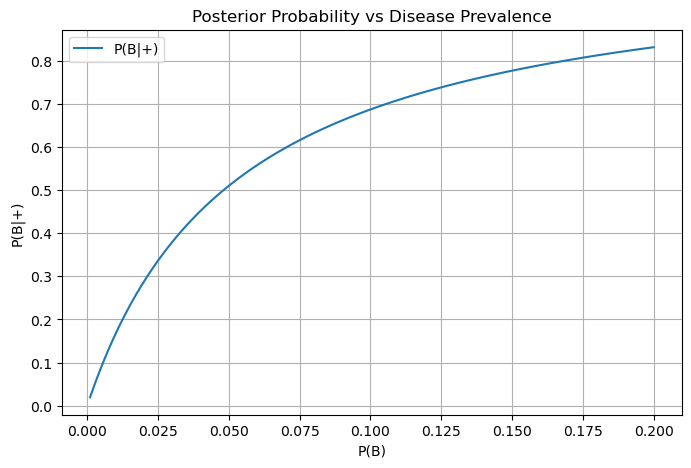

In [81]:
P_B = np.linspace(0.001, 0.2, 100)

P_pos_givenB = 0.99
P_pos_givenNB = 0.05

P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1 - P_B)
P_B_given_pos = P_pos_givenB * P_B / P_pos

plt.figure(figsize=(8,5))

plt.plot(P_B, P_B_given_pos, label="P(B|+)")

plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.title("Posterior Probability vs Disease Prevalence")

plt.legend()
plt.grid(True)

plt.show()

Giải thích : 

Khi bệnh rất hiếm, số người khỏe mạnh chiếm đa số trong dân số. Mặc dù xác suất dương tính giả chỉ là 5%, nhưng thử nghiệm lên một số lượng rất lớn người khỏe sẽ tạo ra nhiều kết quả dương tính giả. Do đó, trong tất cả các trường hợp có kết quả dương tính, tỷ lệ người thực sự mắc bệnh vẫn không cao. Đây là hiện tượng "phản trực giác" và cho thấy cần xem xét cả tỷ lệ mắc bệnh ban đầu (base rate), không chỉ độ chính xác của xét nghiệm. 

Tóm lại, ý nghĩa của định lý Bayes trong bài toán này là "Một tỷ lệ nhỏ của một nhóm rất lớn vẫn có thể lớn hơn một tỷ lệ lớn của một nhóm rất nhỏ". 